# Optuna analysis — диагностика тюнинга CG и joint

Что ищем:
1. **Corner-of-space** для per-CG студий (`cg_*.db`) — best value на границе search space?
2. **Importance + scatter** для `joint.db` — какие param реально двигают score, какие n_cand упёрлись в границы.
3. **Budget** — сумма n_cand vs cap=1600.
4. **Search space drift** — менялся ли search space mid-study (как у `cg_als.alpha`).

Вывод — список конкретных действий для Phase 2 (heuristic re-tune) и Phase 3 (расширение n_cand bounds в anti-overfit joint Optuna).

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

OPTUNA_DIR = Path("../artifacts/optuna")
STUDIES = {
    "cg_decaypop": "cg_decaypop.db",
    "cg_als": "cg_als.db",
    "cg_repeat": "cg_repeat.db",
    "cg_itemknn": "cg_itemknn_best.db",
    "cg_artist_pop": "cg_artist_pop.db",
    "cg_album_pop": "cg_album_pop.db",
    "cg_recent_likes": "cg_recent_likes.db",
    "cg_audio_knn": "cg_audio_knn.db",
    "joint": "joint.db",
}

def load_study(study_name: str) -> optuna.Study:
    db_path = OPTUNA_DIR / STUDIES[study_name]
    return optuna.load_study(study_name=study_name, storage=f"sqlite:///{db_path}")

studies = {name: load_study(name) for name in STUDIES}
for name, st in studies.items():
    n_complete = sum(t.state == optuna.trial.TrialState.COMPLETE for t in st.trials)
    print(f"{name:18s} | trials={len(st.trials):4d} (complete={n_complete:4d}) | best={st.best_value:.4f}")

/Users/astrofimuk/REPS/mla_contest_04-2026/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cg_decaypop        | trials=  75 (complete=  75) | best=115.9478
cg_als             | trials=  17 (complete=  15) | best=362.4341
cg_repeat          | trials=  50 (complete=  50) | best=498.9740
cg_itemknn         | trials=  29 (complete=  26) | best=450.3338
cg_artist_pop      | trials=  32 (complete=  30) | best=332.7541
cg_album_pop       | trials=  30 (complete=  30) | best=220.3590
cg_recent_likes    | trials=  75 (complete=  75) | best=212.4708
cg_audio_knn       | trials=  21 (complete=  20) | best=65.6015
joint              | trials= 142 (complete= 141) | best=413.5619


## 1. Corner-of-space check (per-CG)

Для каждого param вытаскиваем best value, search space (low/high), тип и log-scale. Считаем **proximity to bound**: насколько best близко к нижней или верхней границе (в log-space если distribution log-scale).

Если `corner_score > 0.85` — best прижат к границе, т.е. **search space слишком узкий** или результат в опасной зоне.

In [2]:
def corner_score(value, low, high, log: bool) -> float:
    """0 = середина диапазона, 1 = на границе. -value на нижней, +value на верхней."""
    if log and low > 0 and high > 0 and value > 0:
        v, lo, hi = np.log(value), np.log(low), np.log(high)
    else:
        v, lo, hi = value, low, high
    if hi == lo:
        return 0.0
    rel = (v - lo) / (hi - lo)
    return 2.0 * rel - 1.0  # [-1, 1]; |.| близко к 1 = corner

def per_cg_corner_report(study_name: str) -> pd.DataFrame:
    st = studies[study_name]
    best = st.best_trial
    rows = []
    for pname, val in best.params.items():
        dist = best.distributions[pname]
        if hasattr(dist, "low") and hasattr(dist, "high"):
            log = getattr(dist, "log", False)
            low, high = dist.low, dist.high
            cs = corner_score(val, low, high, log)
            flag = "⚠ CORNER" if abs(cs) > 0.85 else ""
            rows.append({
                "param": pname,
                "best_value": val,
                "low": low,
                "high": high,
                "log": log,
                "corner_score": cs,
                "flag": flag,
            })
    return pd.DataFrame(rows)

for name in [n for n in STUDIES if n.startswith("cg_")]:
    print(f"\n=== {name} (best={studies[name].best_value:.4f}) ===")
    df = per_cg_corner_report(name)
    print(df.to_string(index=False))


=== cg_decaypop (best=115.9478) ===
          param  best_value   low    high  log  corner_score flag
half_life_units      106299 86400 1036800 True       -0.8332     

=== cg_als (best=362.4341) ===
                 param  best_value    low  high   log  corner_score     flag
               factors         991    128  1024  True        0.9685 ⚠ CORNER
            iterations          23     10    30 False           0.3         
        regularization    0.000158 0.0001     1  True       -0.9006 ⚠ CORNER
                 alpha      0.5098    0.5   100  True       -0.9927 ⚠ CORNER
 low_engagement_weight      0.3909      0   0.5 False        0.5637         
high_engagement_weight        3.92    1.5     5 False        0.3828         

=== cg_repeat (best=498.9740) ===
          param  best_value   low    high  log  corner_score     flag
half_life_units      877488 86400 1036800 True        0.8657 ⚠ CORNER

=== cg_itemknn (best=450.3338) ===
param  best_value  low  high   log  corner_score 

## 2. Search space drift — менялись ли границы mid-study?

Уже знаем, что `cg_als.alpha` менялся с `[1.0, 100.0]` на `[0.5, 100.0]` и best (alpha=0.51) сразу прижался к новой нижней границе. Проверяем все CG-студии — есть ли ещё такие случаи.

In [3]:
import sqlite3

def search_space_drift(db_filename: str) -> pd.DataFrame:
    db = sqlite3.connect(OPTUNA_DIR / db_filename)
    df = pd.read_sql_query(
        """
        SELECT tp.param_name, tp.distribution_json, COUNT(*) AS n_trials,
               MIN(t.number) AS first_trial, MAX(t.number) AS last_trial
        FROM trial_params tp JOIN trials t ON tp.trial_id = t.trial_id
        GROUP BY tp.param_name, tp.distribution_json
        """,
        db,
    )
    db.close()
    drift = df.groupby("param_name").filter(lambda g: len(g) > 1)
    return drift

for name, fname in STUDIES.items():
    drift = search_space_drift(fname)
    if not drift.empty:
        print(f"\n=== {name}: search space drift detected ===")
        for pname, group in drift.groupby("param_name"):
            print(f"  param: {pname}")
            for _, row in group.iterrows():
                d = json.loads(row["distribution_json"])
                attrs = d.get("attributes", {})
                print(f"    trials [{row['first_trial']}..{row['last_trial']}] (n={row['n_trials']}): "
                      f"low={attrs.get('low')}, high={attrs.get('high')}, log={attrs.get('log')}")


=== cg_als: search space drift detected ===
  param: alpha
    trials [14..16] (n=3): low=0.5, high=100.0, log=True
    trials [0..13] (n=14): low=1.0, high=100.0, log=True
  param: factors
    trials [14..16] (n=3): low=128, high=1024, log=True
    trials [0..13] (n=14): low=64, high=512, log=True
  param: regularization
    trials [14..16] (n=3): low=0.0001, high=1.0, log=True
    trials [0..13] (n=14): low=0.001, high=1.0, log=True

=== cg_itemknn: search space drift detected ===
  param: k
    trials [20..28] (n=9): low=1, high=100, log=False
    trials [0..19] (n=20): low=50, high=500, log=False


## 3. Joint Optuna — param importance

Чтобы понять какие n_cand_X / ranker params реально двигают score, считаем importance через fANOVA evaluator. CG с очень низкой importance — кандидаты на снижение n_cand (или удаление).

              param  importance category
  n_cand_artist_pop      0.2762   n_cand
        l2_leaf_reg      0.1899   ranker
n_cand_recent_likes      0.1845   n_cand
    n_cand_decaypop     0.07086   n_cand
   n_cand_album_pop     0.06895   n_cand
         n_cand_als     0.04944   n_cand
      n_cand_repeat     0.04755   n_cand
      learning_rate     0.03545   ranker
     n_cand_itemknn     0.03514   n_cand
   n_cand_audio_knn     0.03023   n_cand
              depth    0.007365   ranker
         iterations    0.004456   ranker


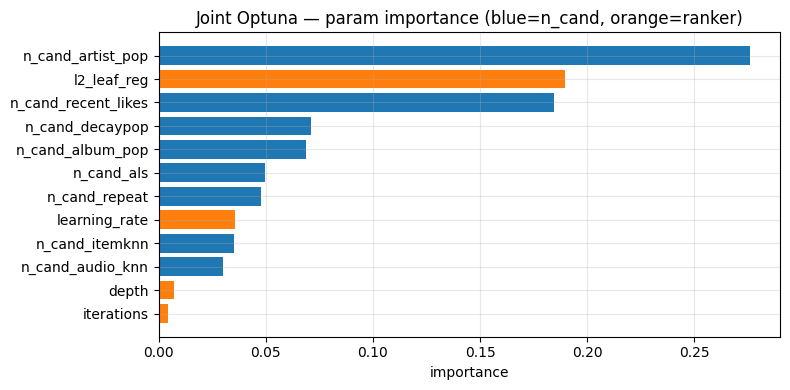

In [4]:
joint = studies["joint"]
imp = optuna.importance.get_param_importances(joint)
imp_df = pd.DataFrame({
    "param": list(imp.keys()),
    "importance": list(imp.values()),
}).sort_values("importance", ascending=False).reset_index(drop=True)
imp_df["category"] = imp_df["param"].apply(lambda p: "n_cand" if p.startswith("n_cand_") else "ranker")
print(imp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tab:blue" if c == "n_cand" else "tab:orange" for c in imp_df["category"]]
ax.barh(imp_df["param"], imp_df["importance"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("importance")
ax.set_title("Joint Optuna — param importance (blue=n_cand, orange=ranker)")
plt.tight_layout()
plt.show()

## 4. Joint — n_cand vs score scatter

Для каждого `n_cand_X` строим scatter (param vs trial value). Если виден монотонный тренд к границе диапазона `[25, 350]` — этот CG **недотюнен** и стоит расширить bounds в Phase 3.

Complete trials: 141
n_cand columns: ['params_n_cand_album_pop', 'params_n_cand_als', 'params_n_cand_artist_pop', 'params_n_cand_audio_knn', 'params_n_cand_decaypop', 'params_n_cand_itemknn', 'params_n_cand_recent_likes', 'params_n_cand_repeat']


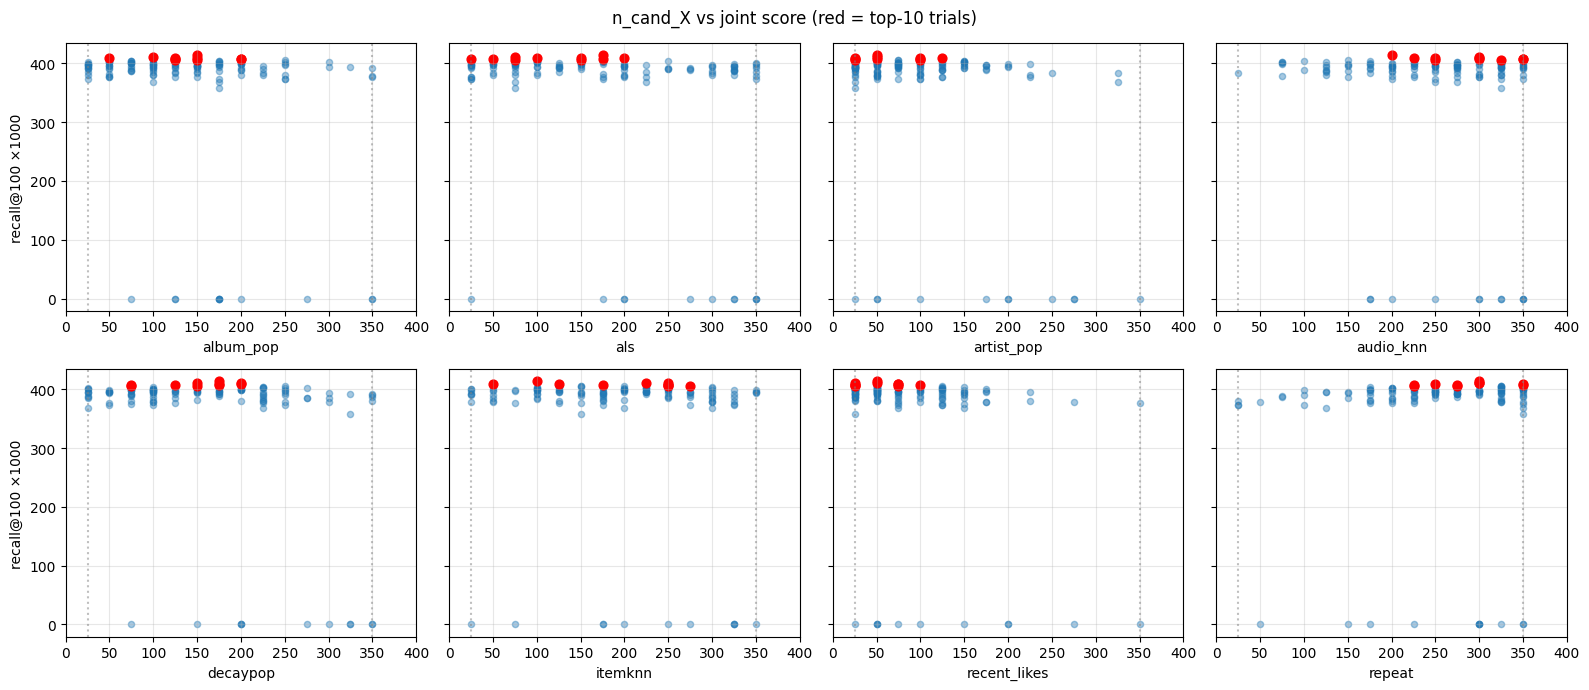

          cg  best_n_cand  top10_mean_n_cand  near_lower(25)  near_upper(350)
   audio_knn          200                285           False            False
      repeat          300                285           False            False
     itemknn          100                195           False            False
    decaypop          175                150           False            False
   album_pop          150              137.5           False            False
         als          175              117.5           False            False
  artist_pop           50                 65            True            False
recent_likes           50               52.5            True            False


In [5]:
trials_df = joint.trials_dataframe(attrs=("number", "value", "params", "state"))
trials_df = trials_df[trials_df["state"] == "COMPLETE"].copy()
n_cand_cols = [c for c in trials_df.columns if c.startswith("params_n_cand_")]
print(f"Complete trials: {len(trials_df)}")
print(f"n_cand columns: {n_cand_cols}")

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
best_value = trials_df["value"].max()
for ax, col in zip(axes.flat, n_cand_cols):
    cg_short = col.replace("params_n_cand_", "")
    ax.scatter(trials_df[col], trials_df["value"], alpha=0.4, s=20)
    # highlight top-10 trials
    top10 = trials_df.nlargest(10, "value")
    ax.scatter(top10[col], top10["value"], color="red", s=40, label="top-10")
    ax.set_xlabel(cg_short)
    ax.set_xlim(0, 400)
    ax.axvline(25, color="gray", ls=":", alpha=0.5)
    ax.axvline(350, color="gray", ls=":", alpha=0.5)
axes[0, 0].set_ylabel("recall@100 ×1000")
axes[1, 0].set_ylabel("recall@100 ×1000")
fig.suptitle("n_cand_X vs joint score (red = top-10 trials)")
plt.tight_layout()
plt.show()

# Summary table: per-CG best, mean of top-10 n_cand, distance to bounds
rows = []
for col in n_cand_cols:
    cg = col.replace("params_n_cand_", "")
    top10_mean = trials_df.nlargest(10, "value")[col].mean()
    best_val = trials_df.loc[trials_df["value"].idxmax(), col]
    rows.append({
        "cg": cg,
        "best_n_cand": int(best_val),
        "top10_mean_n_cand": round(top10_mean, 1),
        "near_lower(25)": top10_mean < 75,
        "near_upper(350)": top10_mean > 300,
    })
summary = pd.DataFrame(rows).sort_values("top10_mean_n_cand", ascending=False)
print(summary.to_string(index=False))

## 5. Budget — сколько использовали из 1600

Best trial #131: value=413.5619, total_budget=1200
Top-10 trials avg budget: 1287.5
Cap (config): 1600


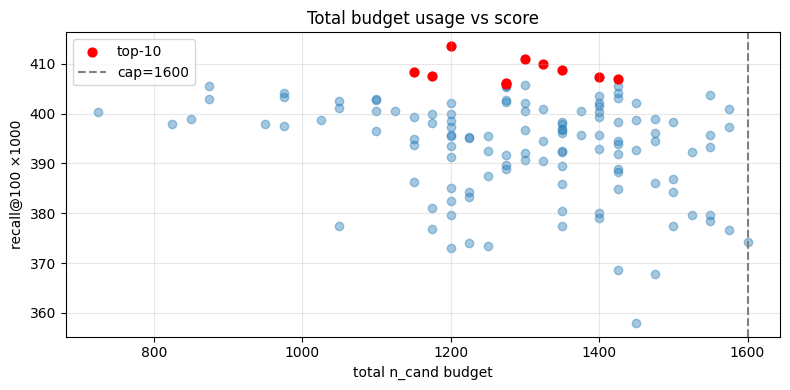

In [19]:
trials_df["total_budget"] = trials_df[n_cand_cols].sum(axis=1)
best_row = trials_df.loc[trials_df["value"].idxmax()]

trials_df = trials_df[trials_df['value'] > 0]

print(f"Best trial #{int(best_row['number'])}: value={best_row['value']:.4f}, total_budget={int(best_row['total_budget'])}")
print(f"Top-10 trials avg budget: {trials_df.nlargest(10, 'value')['total_budget'].mean():.1f}")
print(f"Cap (config): 1600")

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(trials_df["total_budget"], trials_df["value"], alpha=0.4)
top10 = trials_df.nlargest(10, "value")
ax.scatter(top10["total_budget"], top10["value"], color="red", s=40, label="top-10")
ax.axvline(1600, color="gray", ls="--", label="cap=1600")
ax.set_xlabel("total n_cand budget")
ax.set_ylabel("recall@100 ×1000")
ax.set_title("Total budget usage vs score")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
trials_df.sort_values(by="value", ascending=False).head(20)

,number,value,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_n_cand_album_pop,params_n_cand_als,params_n_cand_artist_pop,params_n_cand_audio_knn,params_n_cand_decaypop,params_n_cand_itemknn,params_n_cand_recent_likes,params_n_cand_repeat,state,total_budget
131,131,413.6,8,3500,1.264,0.1346,150,175,50,200,175,100,50,300,COMPLETE,1200
68,68,410.9,8,4000,1.361,0.1162,100,75,50,300,200,225,50,300,COMPLETE,1300
76,76,410,8,3500,2.209,0.1468,50,150,100,300,150,250,25,300,COMPLETE,1325
133,133,408.8,8,3000,1.597,0.1186,125,200,125,250,175,50,75,350,COMPLETE,1350
124,124,408.3,8,3500,1.649,0.1307,150,100,25,225,200,125,75,250,COMPLETE,1150
93,93,407.6,8,3250,1.145,0.1071,125,50,25,350,75,175,25,350,COMPLETE,1175
50,50,407.4,8,3000,1.26,0.1349,200,175,50,300,175,250,25,225,COMPLETE,1400
80,80,406.9,8,3250,1.336,0.134,200,25,100,350,125,250,100,275,COMPLETE,1425
64,64,406.1,8,2500,1.045,0.1431,150,150,100,250,75,250,75,225,COMPLETE,1275
75,75,405.9,8,4000,1.733,0.1111,125,75,25,325,150,275,25,275,COMPLETE,1275


## 6. Joint — ranker params (best vs distribution)

Проверяем corner-of-space для 4 ranker hyperparams в joint.

In [7]:
best_joint = joint.best_trial
rows = []
for pname in ["iterations", "depth", "learning_rate", "l2_leaf_reg"]:
    val = best_joint.params[pname]
    dist = best_joint.distributions[pname]
    log = getattr(dist, "log", False)
    cs = corner_score(val, dist.low, dist.high, log)
    rows.append({
        "param": pname,
        "best": val,
        "low": dist.low,
        "high": dist.high,
        "log": log,
        "corner_score": round(cs, 3),
        "flag": "⚠ CORNER" if abs(cs) > 0.85 else "",
    })
print(pd.DataFrame(rows).to_string(index=False))

        param   best  low  high   log  corner_score     flag
   iterations   3500 1500  4000 False           0.6         
        depth      8    4     8 False             1 ⚠ CORNER
learning_rate 0.1346 0.02  0.15  True         0.893 ⚠ CORNER
  l2_leaf_reg  1.264    1    20  True        -0.844         


## 7. Финальные рекомендации (вывод этой секции вручную после запуска ячеек)

По результатам ячеек 1-6 здесь надо:

- Для Phase 2 (heuristic re-tune): подтвердить, что ALS alpha и/или ItemKNN k действительно сидят на границе search space (corner_score близок к ±1).
- Для Phase 3 (anti-overfit joint Optuna):
  - Какие `n_cand_X` пёрлись к 350 (`near_upper=True` в summary table) → расширить upper до 500.
  - Какие `n_cand_X` сидят у 25 (`near_lower=True`) → можно убрать CG из ансамбля или зафиксировать low.
  - Какие ranker params на границе (corner_score > 0.85) → расширить.
  - Total budget недоиспользован? Если да → не повышать cap, понизить (или оставить).

**Action items записать в `docs/experiment-log.md` под `# Optuna analysis 2026-05-05`.**